# Candidate models

Two candidates, run through the harness built in `04_evaluation.ipynb`, plus the
naive baseline for reference. Both candidates share the same features, the same
log target and the same corrupted-row exclusion, so any difference between them
is a difference in the model, not in the inputs.

They differ in one respect that the fold scores alone will not reveal: whether
they can carry the time trend past the last training date. The December chart
depends entirely on that, so this notebook tests it directly rather than
inferring it from the error metrics.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import clean, load_raw
from src.evaluation import cross_validate
from src.features import attach_coordinates, build_city_coordinates
from src.model import coefficient_table, make_boosted, make_linear, median_rate_per_mile

TEAL, RUST, GREY = "#064A56", "#B4531F", "#9DAFB3"
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.color": "#E2E9EA",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "font.size": 10,
})
pd.set_option("display.width", 200)

train, _ = clean(load_raw("train_test.csv"))
validation, _ = clean(load_raw("validation.csv"))
print(f"training rows {len(train):,}   flagged corrupted {train.is_corrupted.sum():,}")

training rows 48,000   flagged corrupted 677


## 2. Fold scores

In [2]:
candidates = {
    "baseline: median $/mile": median_rate_per_mile,
    "ridge (log target)": make_linear().fit_predict,
    "gradient boosting (log target)": make_boosted().fit_predict,
}

summary = []
for label, fit_predict in candidates.items():
    result = cross_validate(train, fit_predict)
    mean = result[result.fold == "mean"].iloc[0]
    summary.append({
        "model": label,
        "clean_mae": mean.clean_mae,
        "clean_median_ape": mean.clean_median_ape,
        "all_mae": mean.all_mae,
        "all_median_ape": mean.all_median_ape,
    })

pd.DataFrame(summary).set_index("model").round(4)

,clean_mae,clean_median_ape,all_mae,all_median_ape
model,,,,
baseline: median $/mile,205.6772,0.0789,255.5796,0.0802
ridge (log target),74.8133,0.0290,126.9242,0.0294
gradient boosting (log target),61.7879,0.0215,113.9909,0.0219


Both candidates beat the baseline by a wide margin: median APE falls from
**7.9%** to **2.9%** (ridge) and **2.2%** (boosting). On these folds boosting is
the better model — roughly 17% lower MAE than ridge — which is the expected
result, since every test date in every fold sits *inside* the range of dates the
model was trained on.

That last clause is doing a lot of work, and section 4 is where it stops holding.

In [3]:
per_fold = cross_validate(train, make_linear().fit_predict)[["fold", "clean_median_ape"]]
per_fold.columns = ["fold", "ridge"]
per_fold["boosting"] = cross_validate(train, make_boosted().fit_predict)["clean_median_ape"]
per_fold.round(4)

,fold,ridge,boosting
0,1,0.048046,0.020207
1,2,0.017829,0.024902
2,3,0.021106,0.019488
3,mean,0.028994,0.021532


Ridge is notably unstable across folds (4.8% on fold 1, 1.8% and 2.1% after),
while boosting stays within a narrow 1.9%–2.5% band. Fold 1 has the least
training history and its test window covers the July market peak — a linear model
cannot bend to that, a tree can.

## 3. What the linear model learned

In [4]:
linear = make_linear().fit(train)
coefficient_table(linear).head(10).round(4)

,feature,coefficient
0,log_distance,0.6254
1,equipment_dry_van,-0.0295
2,equipment_reefer,0.0267
3,distance,0.0256
4,market_index,0.0255
5,weight,0.0241
6,days_since_origin,0.0188
7,pickup_lat,-0.0148
8,delivery_lat,-0.0143
9,haversine_distance,-0.0084


Coefficients are on standardised inputs, so they are directly comparable: each
is the change in `log(rate)` per one standard deviation of that feature.
Distance dominates, as expected for freight. `market_index` and
`days_since_origin` both carry real weight — and `days_since_origin` having a
non-zero coefficient is precisely what lets this model keep moving after the
training window ends.

## 4. The decisive test: does the trend survive past the training window?

The fold scores cannot answer this, because every fold tests on dates the model
has already seen the neighbourhood of. So we ask the question directly.

Take **one fixed load** — Lexington to Fort Wayne, 360 miles, Dry Van, 32,000 lb
— **freeze the market signals at constants**, and move only the date across all
twelve months of 2025. Freezing `market_index` and `quote_signal` matters: it
strips out market-driven movement so that whatever remains is purely what each
model believes about the passage of time itself.

Training data ends 2025-10-31, so November and December are extrapolation.

In [5]:
lookup = build_city_coordinates(train, validation)
probe_dates = pd.to_datetime([f"2025-{month:02d}-15" for month in range(1, 13)])

probe = pd.DataFrame({
    "pickup": "Lexington", "delivery": "Fort Wayne", "distance": 360.0,
    "equipment": "Dry Van", "weight": 32_000.0, "date": probe_dates,
    "market_index": 1.0, "quote_signal": 2.0,
})
probe = attach_coordinates(probe, lookup)

trend = pd.DataFrame({"date": probe_dates})
for label, model in [("ridge", make_linear()), ("boosting", make_boosted())]:
    trend[label] = model.fit(train).predict(probe)
trend["extrapolated"] = trend.date > train.date.max()
trend.round(1)

,date,ridge,boosting,extrapolated
0,2025-01-15,787.7,772.5,False
1,2025-02-15,796.9,775.5,False
2,2025-03-15,801.7,802.7,False
3,2025-04-15,805.7,815.0,False
4,2025-05-15,807.6,820.9,False
5,2025-06-15,819.5,824.1,False
6,2025-07-15,821.6,823.1,False
7,2025-08-15,825.8,822.4,False
8,2025-09-15,835.6,831.2,False
9,2025-10-15,835.1,840.2,False


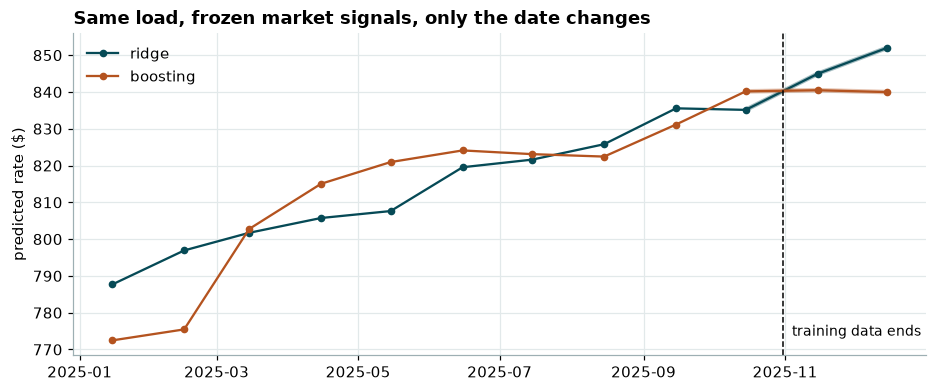

ridge     Jan->Oct (in range)  +6.0%   Oct->Dec (extrapolated)  +2.0%
boosting  Jan->Oct (in range)  +8.8%   Oct->Dec (extrapolated)  -0.0%


In [6]:
fig, ax = plt.subplots(figsize=(10, 3.8))
cutoff = train.date.max()

for label, colour in [("ridge", TEAL), ("boosting", RUST)]:
    ax.plot(trend.date, trend[label], color=colour, marker="o", markersize=4, label=label)
    # Thicken the extrapolated stretch, plus the last in-range point it grows from.
    tail = trend.iloc[len(trend) - int(trend.extrapolated.sum()) - 1:]
    ax.plot(tail.date, tail[label], color=colour, linewidth=3, alpha=0.35)

ax.axvline(cutoff, color="black", linestyle="--", linewidth=1)
ax.annotate("training data ends", xy=(cutoff, 0.06), xycoords=("data", "axes fraction"),
            xytext=(6, 0), textcoords="offset points", fontsize=9)
ax.set_ylabel("predicted rate ($)")
ax.set_title("Same load, frozen market signals, only the date changes",
             loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.show()

in_range = trend[~trend.extrapolated]
beyond = trend[trend.extrapolated]
for label in ("ridge", "boosting"):
    learned = 100 * (in_range[label].iloc[-1] / in_range[label].iloc[0] - 1)
    carried = 100 * (beyond[label].iloc[-1] / in_range[label].iloc[-1] - 1)
    print(f"{label:<9} Jan->Oct (in range) {learned:+5.1f}%   "
          f"Oct->Dec (extrapolated) {carried:+5.1f}%")

**This is the result that decides the model.**

| Model | Trend learned Jan→Oct | Carried Oct→Dec |
|---|---|---|
| ridge | +6.0% | **+2.0%** |
| boosting | +8.8% | **−0.0%** |

Both bracket the ~7% secular drift measured in
`01_exploratory_analysis.ipynb` — boosting slightly over it, ridge slightly
under — so both have clearly picked up a real trend while inside the training
window. And then boosting stops dead: past 2025-10-31 its line is flat to
within a rounding error, while ridge keeps climbing.

This is not a tuning failure and no hyperparameter fixes it. A tree splits on
thresholds observed during training; `days_since_origin = 350` falls on the same
side of every split as the largest value it ever saw, so it lands in the same
leaf as 2025-10-31 and receives the same prediction. Ridge keeps moving because
the trend enters as a coefficient rather than a threshold.

**Consequence:** boosting alone would produce a December chart with no trend and
would under-predict across the whole November–December horizon — exactly the
failure the assessment's fixed-input chart is designed to expose. Ridge alone
extrapolates correctly but gives up meaningful accuracy everywhere else.

Neither candidate is the answer on its own.

## Summary

| Model | clean MAE | clean median APE | Extrapolates trend |
|---|---|---|---|
| baseline: median $/mile | ~$206 | 7.9% | no |
| ridge (log target) | ~$75 | 2.9% | **yes, +2.0%** |
| gradient boosting (log target) | ~$62 | 2.2% | **no, −0.0%** |

* Both candidates beat the baseline by roughly 3–4x on median APE.
* Boosting wins every fold, because folds only test interpolation.
* Boosting cannot extrapolate the trend, and the December chart is entirely an
  extrapolation question.

**Next:** combine them — fit the projectable trend with a linear term, then let
boosting model the residual. That keeps boosting's accuracy on load-specific
structure while retaining a trend that survives past the training window.